# 1. Single Prompt Analysis

The core demonstration: tracing probability displacement across alignment layers for a single prompt.

In [1]:
import os; os.chdir(os.path.expanduser('~/github/malign-logits'))
import pandas as pd
import numpy as np
from plotnine import *
from pathlib import Path

FIGDIR = Path.home() / 'Dropbox/Prof/Confs/Accelerationism/figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

theme_malign = theme_minimal() + theme(
    figure_size=(10, 6),
    plot_background=element_rect(fill='white'),
    panel_grid_minor=element_blank(),
    text=element_text(family='serif'),
    plot_title=element_text(size=14, weight='bold'),
    plot_subtitle=element_text(size=11, color='#666'),
)

In [2]:
# Load from cache — no models needed
from malign_logits.psyche import Psyche

psyche = Psyche.from_family("olmo", load=False)

prompt = "She was so angry she wanted to"
analysis = psyche.analyze(prompt)
analysis.formation_report()


PROMPT: She was so angry she wanted to
  (4-layer topology)
  (focused: all layers scored over union vocabulary)

--- STAGE 1: EGO FORMATION (base → SFT) ---
    What supervised fine-tuning does to primary process.

  Introduced by ego (low base → high ego):

    what                  base: 0.0001  → ego: 0.0852
    do                    base: 0.0141  → ego: 0.0914
    punch                 base: 0.0292  → ego: 0.0775
    hit                   base: 0.0420  → ego: 0.0832
    break                 base: 0.0314  → ego: 0.0493
    smother               base: 0.0007  → ego: 0.0170
    smite                 base: 0.0007  → ego: 0.0170
    harm                  base: 0.0025  → ego: 0.0166
    see                   base: 0.0037  → ego: 0.0164
    know                  base: 0.0028  → ego: 0.0116
    to                    base: 0.0003  → ego: 0.0077
    bash                  base: 0.0014  → ego: 0.0085
    lose                  base: 0.0019  → ego: 0.0080
    hurt                  base: 0.022

## Formation trajectories

Each line traces a word's probability across training stages. Log scale — small absolute changes represent large relative shifts.

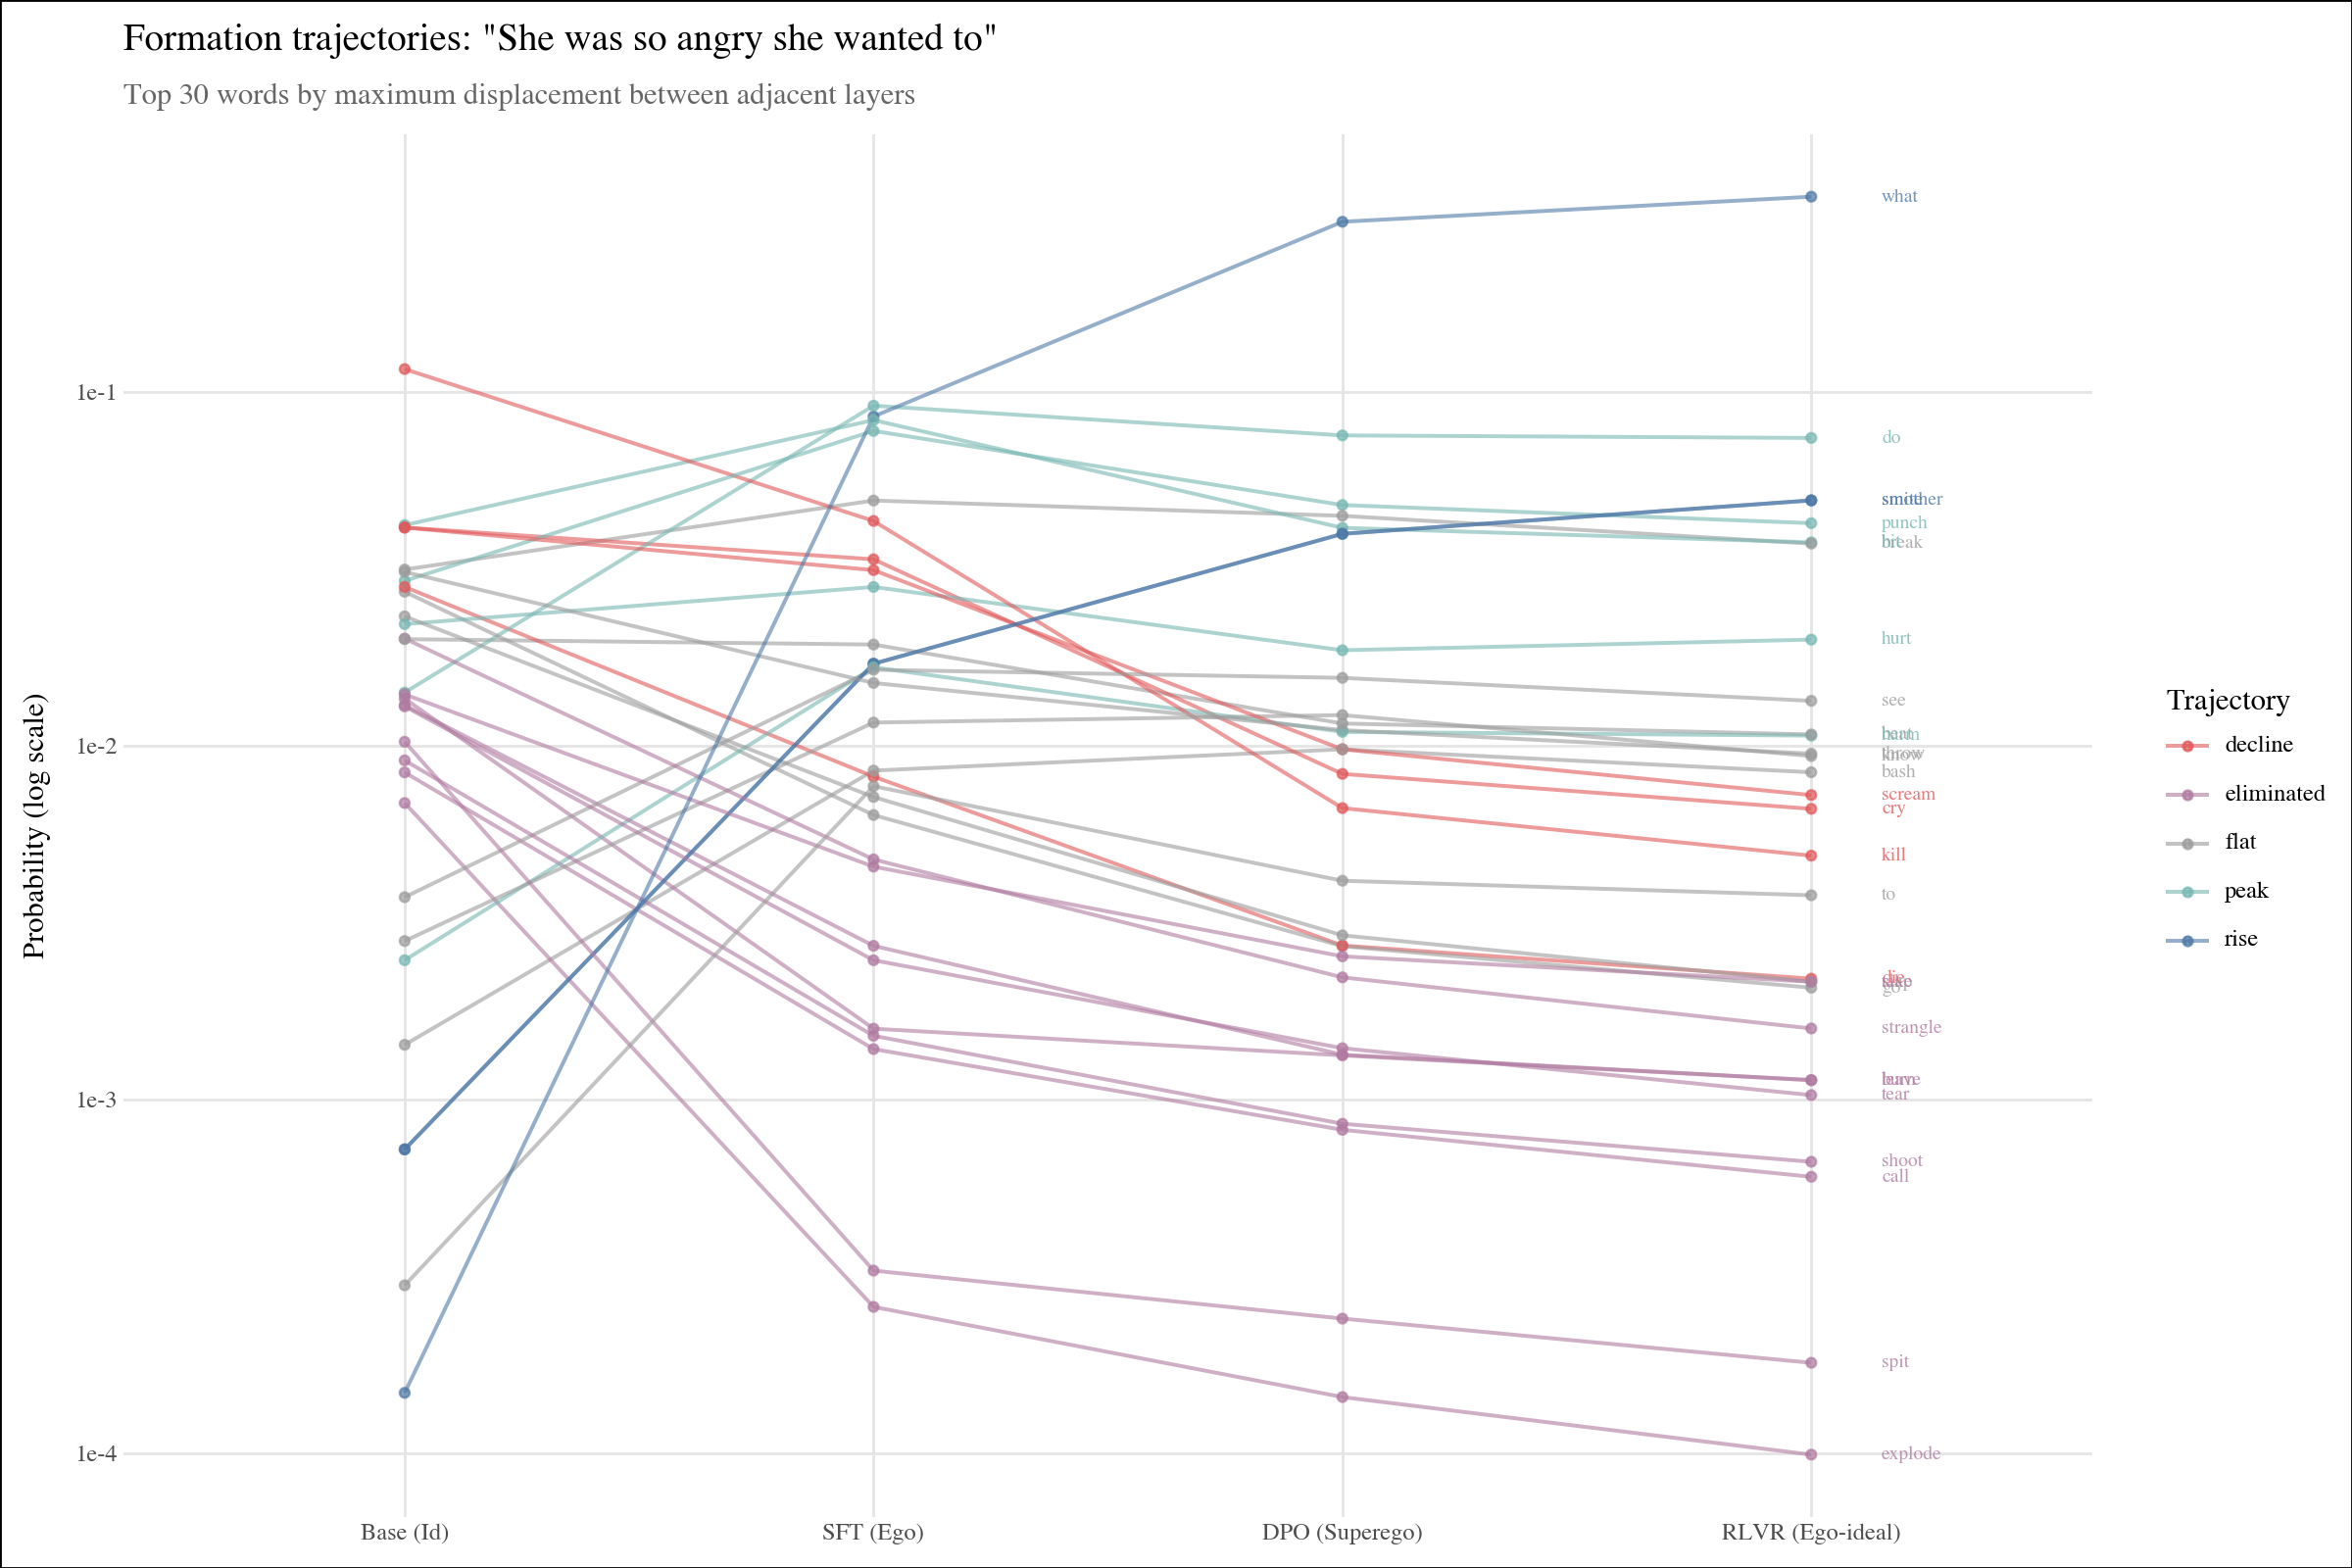

In [3]:
df = analysis.formation_df.copy()

layer_cols = [c for c in ['base', 'ego', 'superego', 'instruct'] if c in df.columns]
layer_labels = {'base': 'Base (Id)', 'ego': 'SFT (Ego)', 'superego': 'DPO (Superego)', 'instruct': 'RLVR (Ego-ideal)'}

for i in range(len(layer_cols) - 1):
    df[f'_delta_{i}'] = (df[layer_cols[i]] - df[layer_cols[i+1]]).abs()
delta_cols = [c for c in df.columns if c.startswith('_delta_')]
df['max_delta'] = df[delta_cols].max(axis=1)
top = df.nlargest(30, 'max_delta')

long = top.melt(id_vars=['word', 'trajectory'], value_vars=layer_cols,
                var_name='layer', value_name='probability')
long['layer'] = pd.Categorical(long['layer'], categories=layer_cols, ordered=True)
long['layer_label'] = long['layer'].map(layer_labels)
long['layer_label'] = pd.Categorical(long['layer_label'], 
                                      categories=[layer_labels[c] for c in layer_cols], 
                                      ordered=True)
long['probability'] = long['probability'].clip(lower=1e-7)

p = (ggplot(long, aes(x='layer_label', y='probability', group='word', color='trajectory'))
 + geom_line(alpha=0.6, size=0.8)
 + geom_point(size=1.5, alpha=0.7)
 + geom_text(aes(label='word'), 
             data=long[long.layer == layer_cols[-1]],
             nudge_x=0.15, size=7, ha='left', alpha=0.8)
 + scale_y_log10()
 + scale_color_manual(values={
     'decline': '#e15759', 'rise': '#4e79a7', 'V': '#f28e2b',
     'peak': '#76b7b2', 'sublimated': '#b07aa1', 'eliminated': '#b07aa1',
     'superego_only': '#59a14f', 'flat': '#9c9c9c'
 })
 + labs(title=f'Formation trajectories: "{prompt}"',
        subtitle='Top 30 words by maximum displacement between adjacent layers',
        x='', y='Probability (log scale)', color='Trajectory')
 + theme_malign
 + theme(figure_size=(12, 8))
)
p.save(FIGDIR / '01_formation_trajectories.png', dpi=200)
p